# Regression Track — Life Expectancy (WHO) Dataset
### 23CSE301 Machine Learning — Capstone Project (Review 1)

**Objective**: Predict life expectancy (continuous target) using socio-economic and health indicators for 193 countries (2000–2015), training and comparing 10 regression algorithms.

**Dataset source**: WHO Global Health Observatory / Kaggle — [Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)


## 1. Imports & Setup

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (10, 6)

## Section A — Dataset & EDA
### A1. Dataset Loading & Audit

In [4]:
df=pd.read_csv("../data/regression/Life Expectancy Data.csv")
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [7]:
df.columns = df.columns.str.strip()
df.rename(columns={'Life expectancy': 'Life_expectancy'}, inplace=True)

In [11]:
print("Shape:", df.shape)

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Missing value counts ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n=== Target (Life_expectancy) distribution ===")
print(df['Life_expectancy'].describe())

print("\n=== Status (categorical feature) distribution ===")
print(df['Status'].value_counts())


Shape: (2938, 22)

=== Data types ===
Country                                str
Year                                 int64
Status                                 str
Life_expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

=


**Observation (A1 audit):** This dataset contains 2,938 rows and 22 columns covering 193 countries from 2000–2015. There are 20 numerical columns and 2 text/categorical columns: Country and Status. The dataset has 14 columns with missing values that need to be handled, the largest being Population (22.19%), followed by Hepatitis B (18.82%) and GDP (15.25%). The target column Life_expectancy itself has 10 missing rows, which will be addressed during preprocessing. The Status variable contains 2,426 Developing (82.57%) and 512 Developed (17.43%) observations, indicating an imbalance between the two categories. This will be considered during train/test splitting and subsequent model interpretation.

### A2. EDA Visualisations

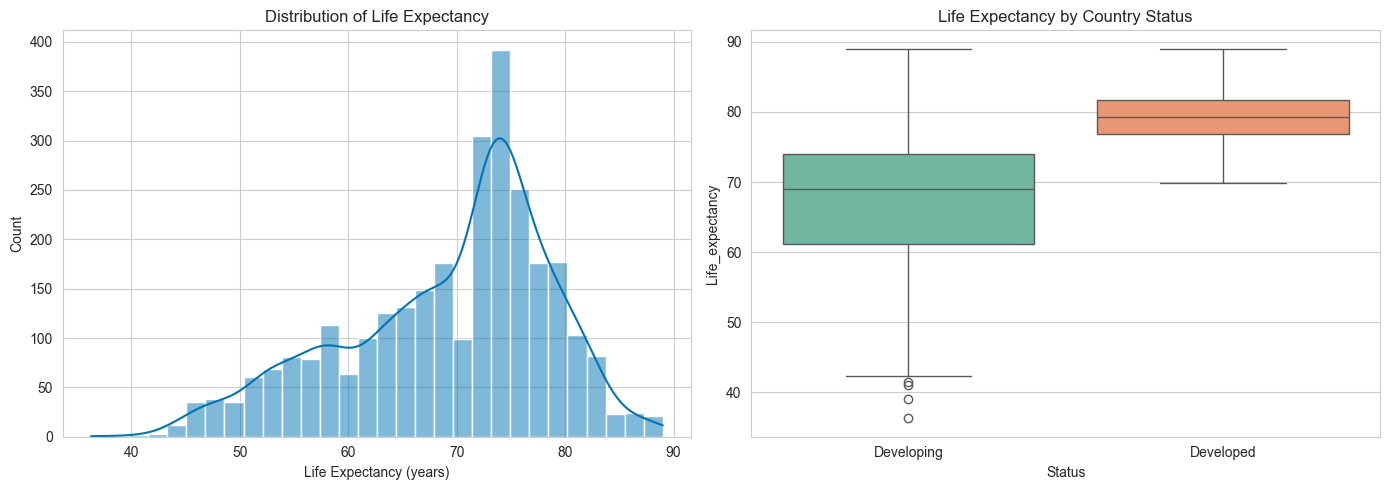

In [23]:
# Target distribution
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(df['Life_expectancy'].dropna(),kde=True,ax=axes[0])
axes[0].set_title('Distribution of Life Expectancy')
axes[0].set_xlabel('Life Expectancy (years)')

sns.boxplot(data=df,x='Status',y='Life_expectancy',ax=axes[1], hue='Status',palette='Set2')
axes[1].set_title('Life Expectancy by Country Status')
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

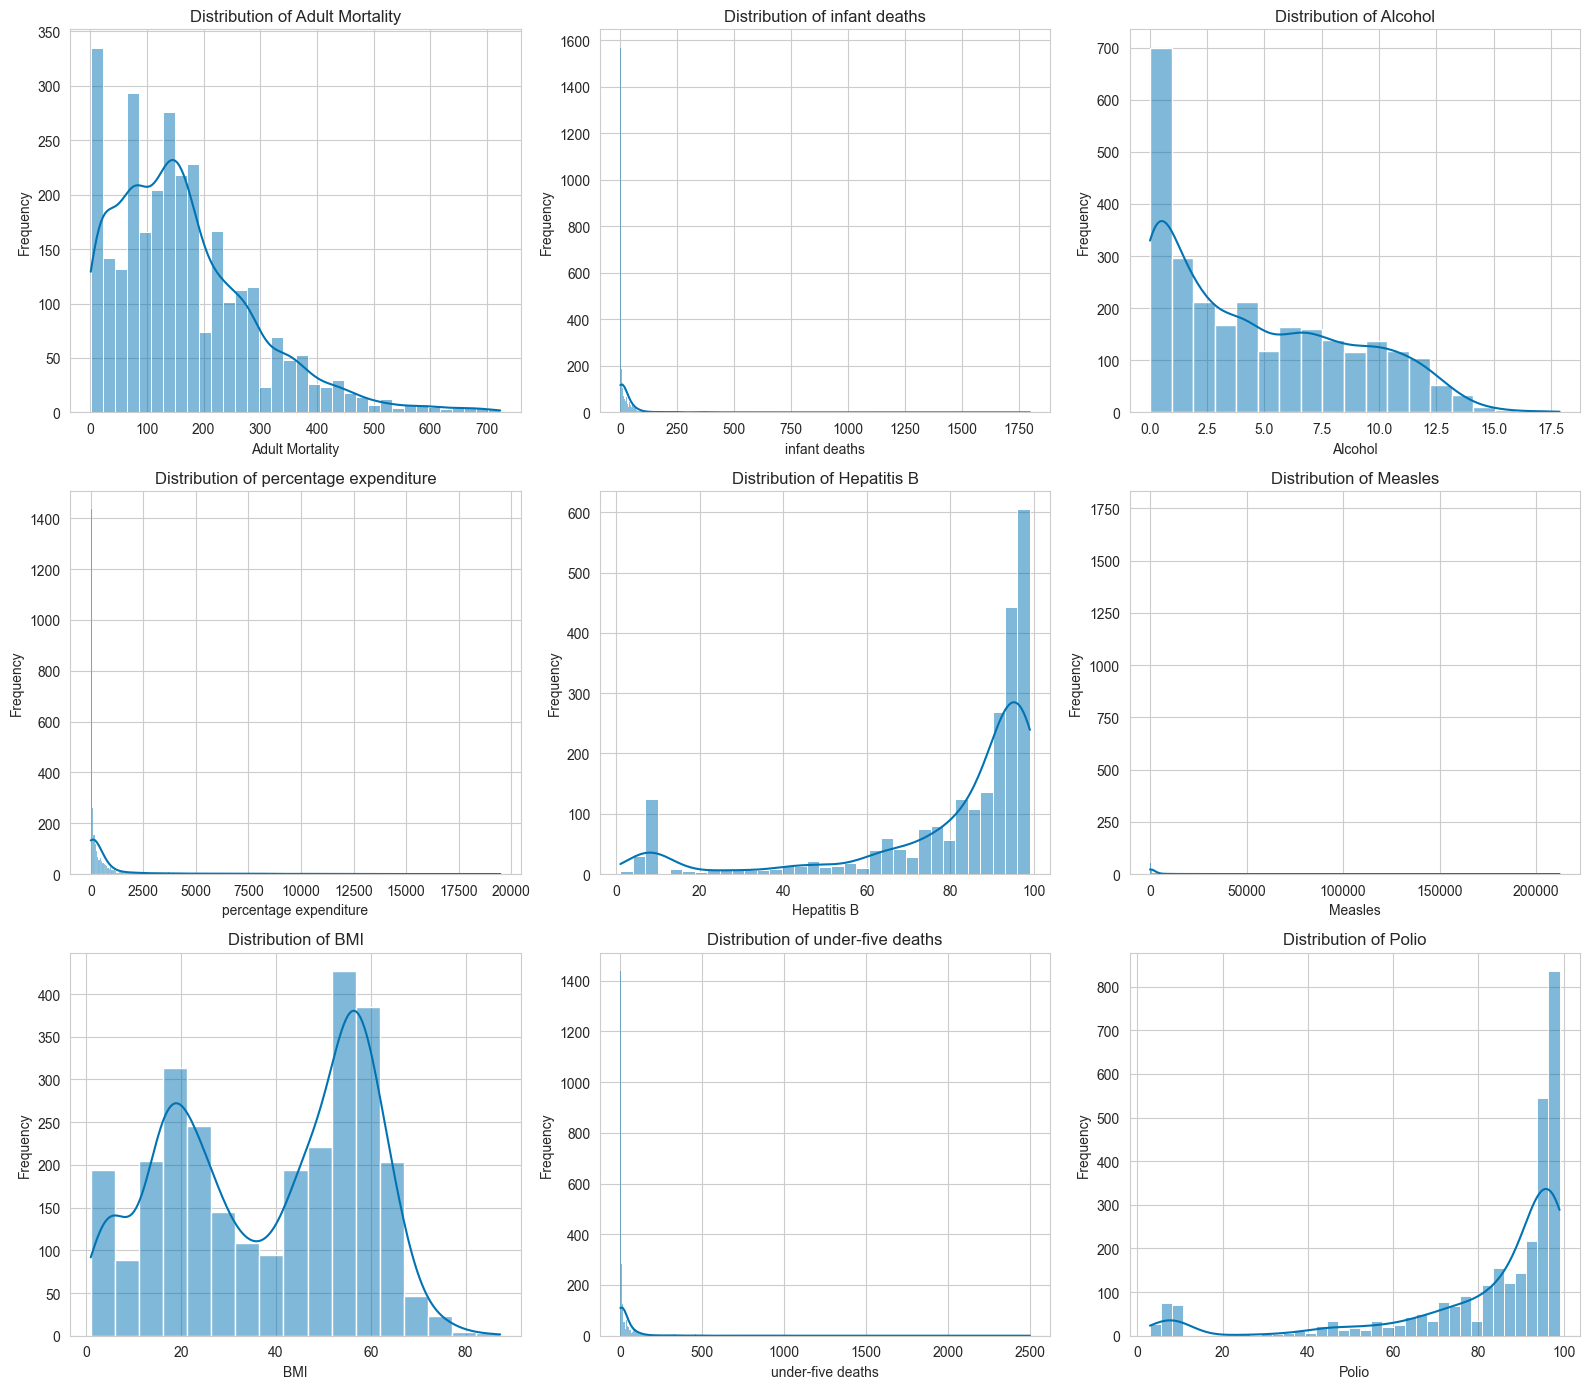

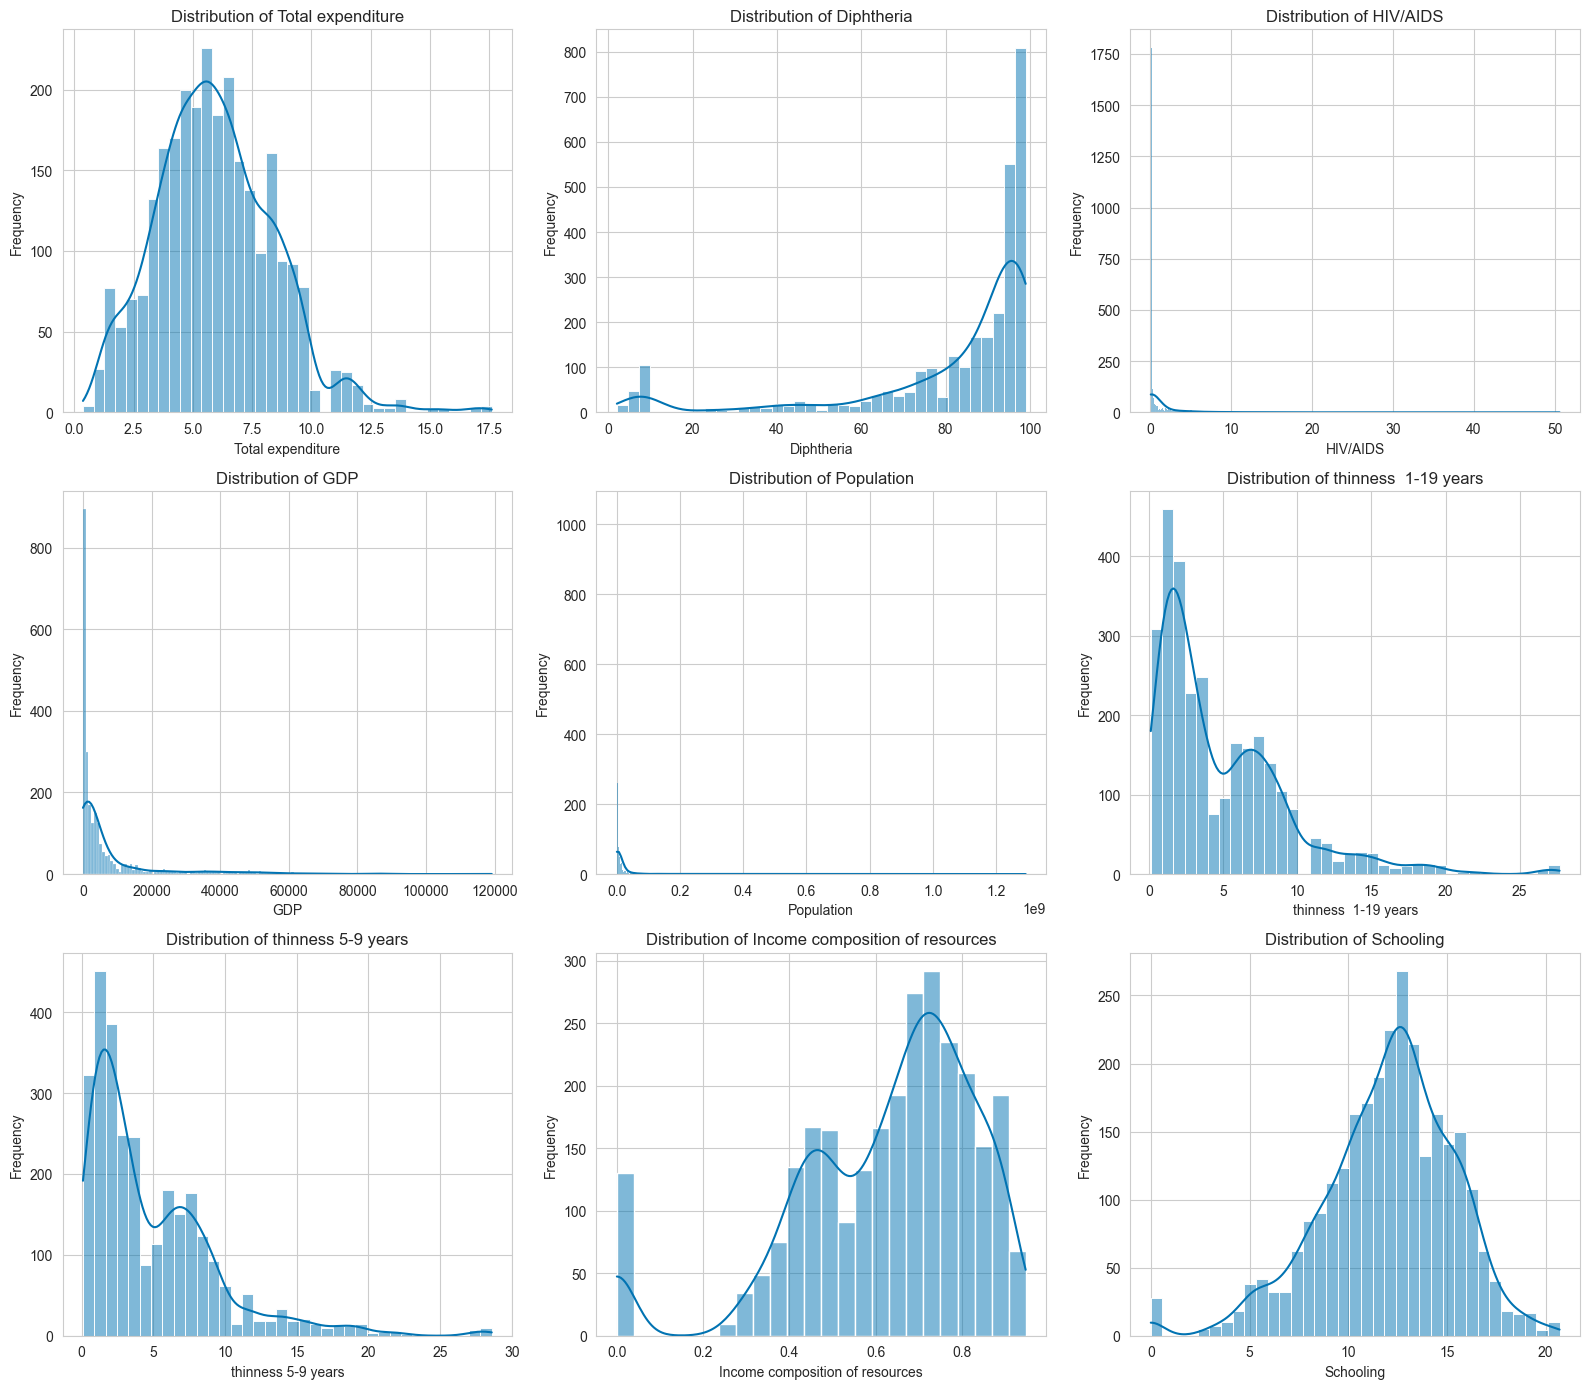

In [47]:
# Distribution plots for all numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('Year')
num_cols.remove('Life_expectancy')


fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), num_cols[:9]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distribution_1.png', bbox_inches='tight', dpi=100)
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), num_cols[9:]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distribution_2.png', bbox_inches='tight', dpi=100)
plt.show()

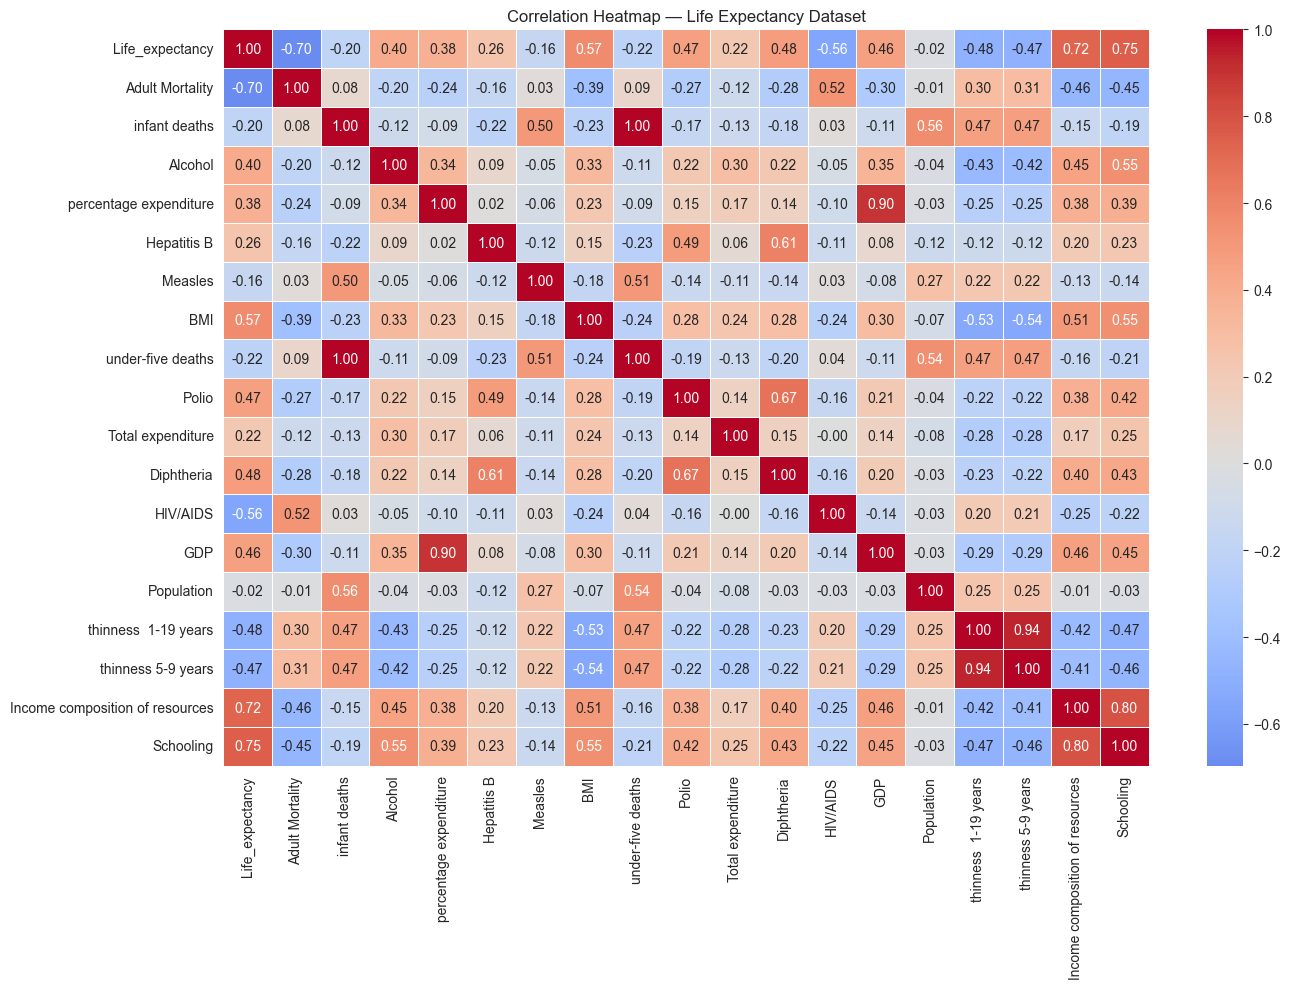

In [45]:
#Correlation heatmap
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Year'])
corr=numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap — Life Expectancy Dataset')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

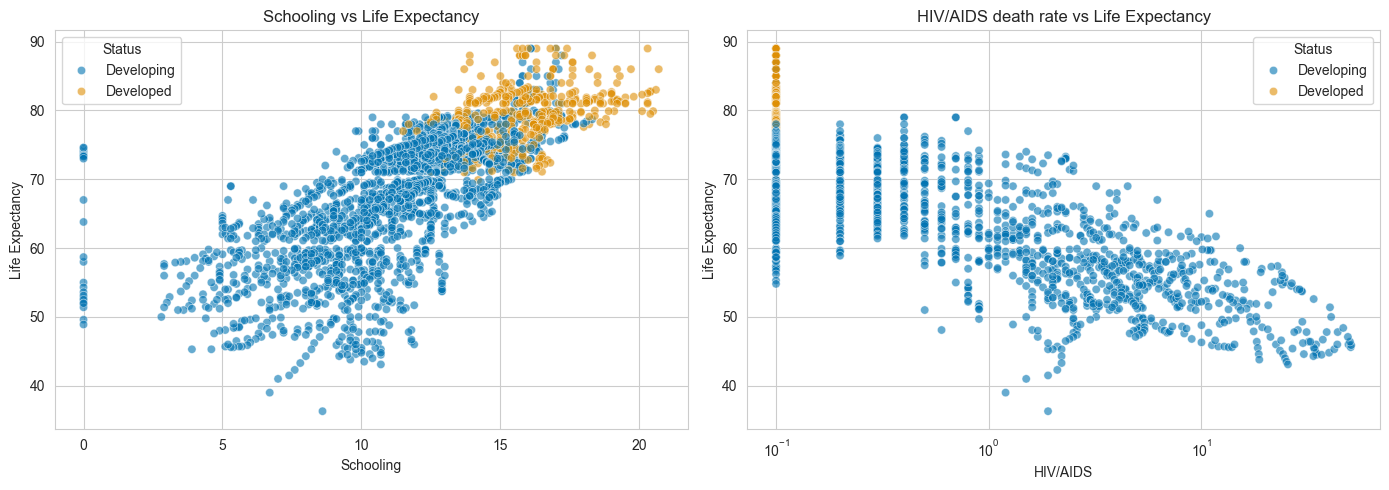

In [48]:
# Scatter plots: feature vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Schooling', y='Life_expectancy', hue='Status', ax=axes[0], alpha=0.6)
axes[0].set_title('Schooling vs Life Expectancy')
axes[0].set_xlabel('Schooling')
axes[0].set_ylabel('Life Expectancy')

sns.scatterplot(data=df, x='HIV/AIDS', y='Life_expectancy', hue='Status', ax=axes[1], alpha=0.6)
axes[1].set_title('HIV/AIDS death rate vs Life Expectancy')
axes[1].set_xscale('log')
axes[1].set_xlabel('HIV/AIDS')
axes[1].set_ylabel('Life Expectancy')

plt.tight_layout()
plt.savefig('scatter_relationships.png', bbox_inches='tight', dpi=100)
plt.show()


### A3. Insight commentary

**Observation:**

- **Target distribution**: Life expectancy is left-skewed — most countries cluster between 65–80 years, with a long tail of lower values pulled down by a small number of countries facing conflict, disease burden, or economic hardship.

- **Feature distributions**: Several features, particularly Population and GDP, are heavily right-skewed — a small number of very large/wealthy countries dominate the scale, while most countries sit near the lower end.

- **Correlation heatmap**: Schooling and Income composition of resources show strong positive correlation with life expectancy, while Adult Mortality and HIV/AIDS show strong negative correlation — consistent with the scatter plots below. The heatmap also reveals notable multicollinearity among the mortality-related features (Adult Mortality, infant deaths, under-five deaths), which motivates using Ridge/Lasso/ElasticNet later, since they handle correlated predictors more robustly than plain Linear Regression.

- **Schooling vs. Life Expectancy (scatter)**: a clear, roughly linear positive relationship — more years of average schooling consistently associates with longer life expectancy, likely reflecting broader healthcare access and economic development in more educated populations.

- **HIV/AIDS vs. Life Expectancy (scatter, log scale)**: a strong negative, non-linear relationship — even modest increases in HIV/AIDS death rate correspond to sharp drops in life expectancy, which is why a log scale was needed to make the relationship visible at all.

- **Status comparison**: The boxplot indicates that Life_expectancy differs between Developed and Developing countries. Developed countries generally show higher life expectancy values, while Developing countries have a wider spread and more observations at lower life expectancy levels.